# Кластеризация датасета Mice Protein Expression

Выбранный датасет: `Mice Protein Expression` с Kaggle.

Ссылка: https://www.kaggle.com/datasets/ruslankl/mice-protein-expression

В датасете измерены уровни экспрессии 77 белков и модификаций белков в коре головного мозга мышей. Объекты можно кластеризовать по похожести белковых профилей, а затем сравнить найденные кластеры с известными группами мышей.(как было на паре с Ирисами)

В датасете есть 8 экспериментальных групп:

- `c-CS-s`: контрольные мыши, стимулированные к обучению, инъекция saline (9 мышей);
- `c-CS-m`: контрольные мыши, стимулированные к обучению, инъекция memantine (10 мышей);
- `c-SC-s`: контрольные мыши, не стимулированные к обучению, инъекция saline (9 мышей);
- `c-SC-m`: контрольные мыши, не стимулированные к обучению, инъекция memantine (10 мышей);
- `t-CS-s`: trisomy-мыши, стимулированные к обучению, инъекция saline (7 мышей);
- `t-CS-m`: trisomy-мыши, стимулированные к обучению, инъекция memantine (9 мышей);
- `t-SC-s`: trisomy-мыши, не стимулированные к обучению, инъекция saline (9 мышей);
- `t-SC-m`: trisomy-мыши, не стимулированные к обучению, инъекция memantine (9 мышей).

In [1]:
import sys
import warnings
from time import perf_counter
from pathlib import Path

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.metrics import pairwise_distances

PROJECT_ROOT = Path.cwd()
for path_candidate in [PROJECT_ROOT, PROJECT_ROOT.parent]:
    if str(path_candidate) not in sys.path:
        sys.path.append(str(path_candidate))

try:
    from task_1.custom_kmeans import CustomKMeansPlusPlus
except ModuleNotFoundError:
    from custom_kmeans import CustomKMeansPlusPlus

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

/home/dabzelos/Desktop/academic-comeback/ml/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Загрузка данных

CSV-файл датасета должен быть сохранён в папке `dataset`. Если файла нет, ноутбук скачает его через `kagglehub`.

In [2]:
local_csv_path = Path('dataset/Data_Cortex_Nuclear.csv')

if local_csv_path.exists():
    csv_path = local_csv_path
else:
    dataset_path = Path(kagglehub.dataset_download('ruslankl/mice-protein-expression'))
    csv_path = next(dataset_path.glob('*.csv'))

csv_path


  0%|          | 0.00/423k [00:00<?, ?B/s]


100%|██████████| 423k/423k [00:02<00:00, 192kB/s]


100%|██████████| 423k/423k [00:02<00:00, 192kB/s]

Extracting files...


PosixPath('/home/dabzelos/.cache/kagglehub/datasets/ruslankl/mice-protein-expression/versions/1/Data_Cortex_Nuclear.csv')

## EDA

### Общий вид датасета

In [3]:
df = pd.read_csv(csv_path)

print(f'Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов')
df.head()

Размер датасета: 1080 строк, 82 столбцов


,MouseID,DYRK1A_N,ITSN1_N,BDNF_N,NR1_N,NR2A_N,pAKT_N,pBRAF_N,pCAMKII_N,pCREB_N,...,pCFOS_N,SYP_N,H3AcK18_N,EGR1_N,H3MeK4_N,CaNA_N,Genotype,Treatment,Behavior,class
0,309_1,0.503644,0.747193,0.430175,2.816329,5.990152,0.218830,0.177565,2.373744,0.232224,...,0.108336,0.427099,0.114783,0.131790,0.128186,1.675652,Control,Memantine,C/S,c-CS-m
1,309_2,0.514617,0.689064,0.411770,2.789514,5.685038,0.211636,0.172817,2.292150,0.226972,...,0.104315,0.441581,0.111974,0.135103,0.131119,1.743610,Control,Memantine,C/S,c-CS-m
2,309_3,0.509183,0.730247,0.418309,2.687201,5.622059,0.209011,0.175722,2.283337,0.230247,...,0.106219,0.435777,0.111883,0.133362,0.127431,1.926427,Control,Memantine,C/S,c-CS-m
3,309_4,0.442107,0.617076,0.358626,2.466947,4.979503,0.222886,0.176463,2.152301,0.207004,...,0.111262,0.391691,0.130405,0.147444,0.146901,1.700563,Control,Memantine,C/S,c-CS-m
4,309_5,0.434940,0.617430,0.358802,2.365785,4.718679,0.213106,0.173627,2.134014,0.192158,...,0.110694,0.434154,0.118481,0.140314,0.148380,1.839730,Control,Memantine,C/S,c-CS-m


### Типы данных

Проверяем названия столбцов, типы данных и количество непустых значений.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1080 entries, 0 to 1079
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   MouseID          1080 non-null   str    
 1   DYRK1A_N         1077 non-null   float64
 2   ITSN1_N          1077 non-null   float64
 3   BDNF_N           1077 non-null   float64
 4   NR1_N            1077 non-null   float64
 5   NR2A_N           1077 non-null   float64
 6   pAKT_N           1077 non-null   float64
 7   pBRAF_N          1077 non-null   float64
 8   pCAMKII_N        1077 non-null   float64
 9   pCREB_N          1077 non-null   float64
 10  pELK_N           1077 non-null   float64
 11  pERK_N           1077 non-null   float64
 12  pJNK_N           1077 non-null   float64
 13  PKCA_N           1077 non-null   float64
 14  pMEK_N           1077 non-null   float64
 15  pNR1_N           1077 non-null   float64
 16  pNR2A_N          1077 non-null   float64
 17  pNR2B_N          1077 non

### Распределение экспериментальных групп

Смотрим, сколько записей относится к каждой группе `class`. Это уже известные группы, с которыми потом можно сравнить найденные кластера.

In [5]:
df['class'].value_counts().sort_index()

class
c-CS-m    150
c-CS-s    135
c-SC-m    150
c-SC-s    135
t-CS-m    135
t-CS-s    105
t-SC-m    135
t-SC-s    135
Name: count, dtype: int64

### Факторы эксперимента

Проверяем, как группы складываются из трёх условий: генотипа, лечения и поведения.

In [6]:
df[['Genotype', 'Treatment', 'Behavior', 'class']].value_counts().sort_index()

Genotype  Treatment  Behavior  class 
Control   Memantine  C/S       c-CS-m    150
                     S/C       c-SC-m    150
          Saline     C/S       c-CS-s    135
                     S/C       c-SC-s    135
Ts65Dn    Memantine  C/S       t-CS-m    135
                     S/C       t-SC-m    135
          Saline     C/S       t-CS-s    105
                     S/C       t-SC-s    135
Name: count, dtype: int64

### Пропущенные значения

Ищем признаки с пропусками. Перед кластеризацией заполним их медианой по столбцу.

In [7]:
missing_by_column = df.isna().sum().sort_values(ascending=False)
missing_by_column[missing_by_column > 0].head(15)

BCL2_N        285
H3MeK4_N      270
BAD_N         213
EGR1_N        210
H3AcK18_N     180
pCFOS_N        75
Bcatenin_N     18
ELK_N          18
MEK_N           7
pCAMKII_N       3
pELK_N          3
BDNF_N          3
NR1_N           3
NR2A_N          3
pAKT_N          3
dtype: int64

### Базовая статистика числовых признаков

Смотрим средние значения, разброс и диапазоны первых числовых признаков. Это показывает, что признаки находятся в разных масштабах, поэтому перед кластеризацией нужно масштабирование.

In [8]:
df.describe().T.head(10)

,count,mean,std,min,25%,50%,75%,max
DYRK1A_N,1077.0,0.425810,0.249362,0.145327,0.288121,0.366378,0.487711,2.516367
ITSN1_N,1077.0,0.617102,0.251640,0.245359,0.473361,0.565782,0.698032,2.602662
BDNF_N,1077.0,0.319088,0.049383,0.115181,0.287444,0.316564,0.348197,0.497160
NR1_N,1077.0,2.297269,0.347293,1.330831,2.057411,2.296546,2.528481,3.757641
NR2A_N,1077.0,3.843934,0.933100,1.737540,3.155678,3.760855,4.440011,8.482553
pAKT_N,1077.0,0.233168,0.041634,0.063236,0.205755,0.231177,0.257261,0.539050
pBRAF_N,1077.0,0.181846,0.027042,0.064043,0.164595,0.182302,0.197418,0.317066
pCAMKII_N,1077.0,3.537109,1.295169,1.343998,2.479834,3.326520,4.481940,7.464070
pCREB_N,1077.0,0.212574,0.032587,0.112812,0.190823,0.210594,0.234595,0.306247
pELK_N,1077.0,1.428682,0.466904,0.429032,1.203665,1.355846,1.561316,6.113347


## Подготовка признаков

Для кластеризации берём только числовые признаки белков. Служебные и категориальные столбцы `MouseID`, `Genotype`, `Treatment`, `Behavior`, `class` не используем как признаки кластеризации.

In [9]:
meta_columns = ['MouseID', 'Genotype', 'Treatment', 'Behavior', 'class']
protein_columns = [
    column for column in df.select_dtypes(include='number').columns
    if column not in meta_columns
]

X = df[protein_columns].copy()

print(f'Количество признаков для кластеризации: {X.shape[1]}')
X.head()

Количество признаков для кластеризации: 77


,DYRK1A_N,ITSN1_N,BDNF_N,NR1_N,NR2A_N,pAKT_N,pBRAF_N,pCAMKII_N,pCREB_N,pELK_N,...,SHH_N,BAD_N,BCL2_N,pS6_N,pCFOS_N,SYP_N,H3AcK18_N,EGR1_N,H3MeK4_N,CaNA_N
0,0.503644,0.747193,0.430175,2.816329,5.990152,0.218830,0.177565,2.373744,0.232224,1.750936,...,0.188852,0.122652,NaN,0.106305,0.108336,0.427099,0.114783,0.131790,0.128186,1.675652
1,0.514617,0.689064,0.411770,2.789514,5.685038,0.211636,0.172817,2.292150,0.226972,1.596377,...,0.200404,0.116682,NaN,0.106592,0.104315,0.441581,0.111974,0.135103,0.131119,1.743610
2,0.509183,0.730247,0.418309,2.687201,5.622059,0.209011,0.175722,2.283337,0.230247,1.561316,...,0.193685,0.118508,NaN,0.108303,0.106219,0.435777,0.111883,0.133362,0.127431,1.926427
3,0.442107,0.617076,0.358626,2.466947,4.979503,0.222886,0.176463,2.152301,0.207004,1.595086,...,0.192112,0.132781,NaN,0.103184,0.111262,0.391691,0.130405,0.147444,0.146901,1.700563
4,0.434940,0.617430,0.358802,2.365785,4.718679,0.213106,0.173627,2.134014,0.192158,1.504230,...,0.205604,0.129954,NaN,0.104784,0.110694,0.434154,0.118481,0.140314,0.148380,1.839730


In [10]:
missing = X.isna().sum().sort_values(ascending=False)
missing[missing > 0].head(15)

BCL2_N        285
H3MeK4_N      270
BAD_N         213
EGR1_N        210
H3AcK18_N     180
pCFOS_N        75
ELK_N          18
Bcatenin_N     18
MEK_N           7
ITSN1_N         3
BDNF_N          3
NR1_N           3
DYRK1A_N        3
PKCA_N          3
pJNK_N          3
dtype: int64

In [11]:
imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()

X_imputed = imputer.fit_transform(X)
X_scaled = scaler.fit_transform(X_imputed)

X_scaled.shape

(1080, 77)

## Обучение и сравнение моделей кластеризации

Обучим несколько моделей кластеризации с подбором гиперпараметров:

- собственная реализация `CustomKMeansPlusPlus`;
- `KMeans` из `sklearn`;
- `DBSCAN` из `sklearn`.

Для выбора числа кластеров у K-Means-подходов используем эвристику локтя, а для сравнения моделей — время обучения и метрики качества: `silhouette_score`, `adjusted_rand_score`, внутрикластерное расстояние, межкластерное расстояние и индекс Данна.

In [12]:
y_true, class_names = pd.factorize(df['class'])


def count_clusters(labels):
    unique_labels = set(labels)
    unique_labels.discard(-1)  # В DBSCAN метка -1 означает шум, а не отдельный кластер.
    return len(unique_labels)


def non_noise_mask(labels):
    return np.asarray(labels) != -1


def cluster_distance_metrics(X_eval, labels):
    labels = np.asarray(labels)
    cluster_labels = [label for label in np.unique(labels) if label != -1]

    if len(cluster_labels) < 2:
        return np.nan, np.nan, np.nan

    mask = non_noise_mask(labels)
    X_no_noise = X_eval[mask]
    labels_no_noise = labels[mask]
    distance_matrix = pairwise_distances(X_no_noise)
    intra_diameters = []
    inter_distances = []

    for label in cluster_labels:
        cluster_indices = np.where(labels_no_noise == label)[0]
        if len(cluster_indices) < 2:
            intra_diameters.append(0)
            continue

        cluster_distances = distance_matrix[np.ix_(cluster_indices, cluster_indices)]
        intra_diameters.append(cluster_distances.max())

    for first_index, first_label in enumerate(cluster_labels):
        first_cluster_indices = np.where(labels_no_noise == first_label)[0]

        for second_label in cluster_labels[first_index + 1:]:
            second_cluster_indices = np.where(labels_no_noise == second_label)[0]
            cluster_distances = distance_matrix[np.ix_(first_cluster_indices, second_cluster_indices)]
            inter_distances.append(cluster_distances.min())

    mean_intra_cluster_distance = np.mean(intra_diameters)
    mean_inter_cluster_distance = np.mean(inter_distances)
    max_intra_cluster_diameter = np.max(intra_diameters)
    min_inter_cluster_distance = np.min(inter_distances)

    if max_intra_cluster_diameter == 0:
        dunn_index = np.nan
    else:
        dunn_index = min_inter_cluster_distance / max_intra_cluster_diameter

    return mean_intra_cluster_distance, mean_inter_cluster_distance, dunn_index


def safe_silhouette_score(X_eval, labels):
    labels = np.asarray(labels)
    mask = non_noise_mask(labels)
    labels_no_noise = labels[mask]
    n_clusters = len(np.unique(labels_no_noise))

    if 2 <= n_clusters < len(labels_no_noise):
        return silhouette_score(X_eval[mask], labels_no_noise)

    return np.nan


def evaluate_clustering(model_name, params, X_eval, labels, fit_time, inertia=None):
    n_clusters = count_clusters(labels)
    noise_count = int(np.sum(labels == -1))
    intra_distance, inter_distance, dunn_index = cluster_distance_metrics(X_eval, labels)

    return {
        'model': model_name,
        'params': params,
        'fit_time_sec': fit_time,
        'n_clusters': n_clusters,
        'noise_count': noise_count,
        'inertia': inertia,
        'intra_cluster_distance': intra_distance,
        'inter_cluster_distance': inter_distance,
        'dunn_index': dunn_index,
        'silhouette': safe_silhouette_score(X_eval, labels),
        'adjusted_rand': adjusted_rand_score(y_true, labels),
    }

### Эвристика локтя для выбора числа кластеров

Для K-Means-подходов главный гиперпараметр — количество кластеров. Построим график для метода локтя: чем больше кластеров, тем меньше сумма расстояний до центров.

In [13]:
k_values = range(2, 13)
elbow_results = []

for n_clusters in k_values:
    custom_model = CustomKMeansPlusPlus(n_clusters=n_clusters, n_init=20, random_state=RANDOM_STATE)
    custom_labels = custom_model.fit_predict(X_scaled)

    sklearn_model = KMeans(
        n_clusters=n_clusters,
        init='k-means++',
        n_init=20,
        random_state=RANDOM_STATE,
    )
    sklearn_labels = sklearn_model.fit_predict(X_scaled)

    elbow_results.append(
        {
            'n_clusters': n_clusters,
            'model': 'CustomKMeansPlusPlus',
            'inertia': custom_model.inertia_,
            'silhouette': silhouette_score(X_scaled, custom_labels),
        }
    )
    elbow_results.append(
        {
            'n_clusters': n_clusters,
            'model': 'sklearn KMeans',
            'inertia': sklearn_model.inertia_,
            'silhouette': silhouette_score(X_scaled, sklearn_labels),
        }
    )

elbow_df = pd.DataFrame(elbow_results)
elbow_df.head()

,n_clusters,model,inertia,silhouette
0,2,CustomKMeansPlusPlus,70064.595731,0.143124
1,2,sklearn KMeans,70064.595731,0.143124
2,3,CustomKMeansPlusPlus,63024.549937,0.128043
3,3,sklearn KMeans,63027.010324,0.128090
4,4,CustomKMeansPlusPlus,58647.195099,0.120551


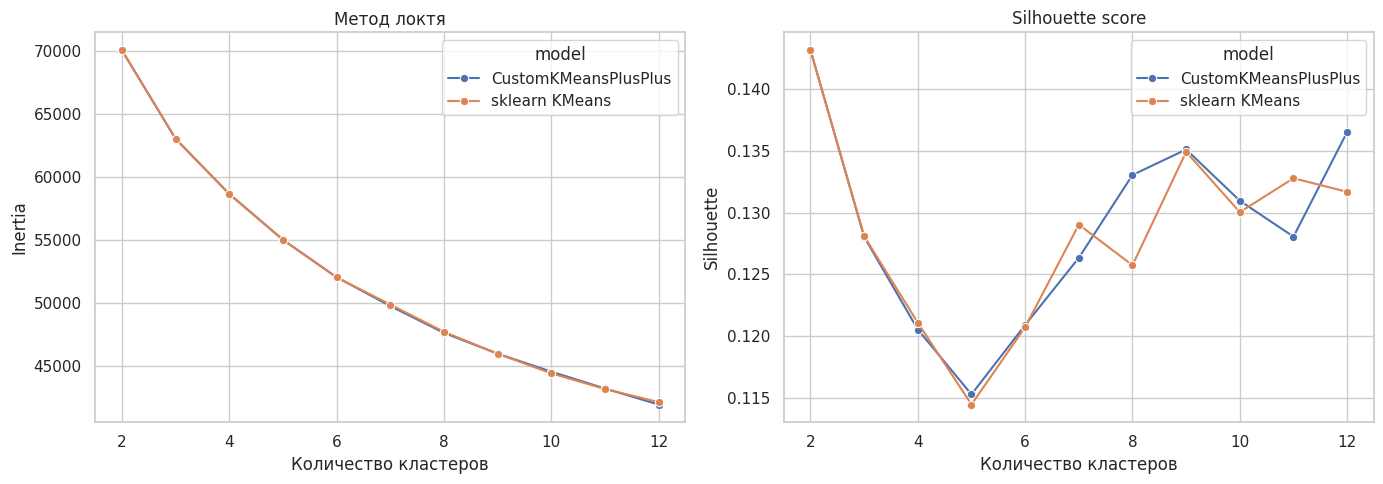

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(
    data=elbow_df,
    x='n_clusters',
    y='inertia',
    hue='model',
    marker='o',
    ax=axes[0],
)
axes[0].set_title('Метод локтя')
axes[0].set_xlabel('Количество кластеров')
axes[0].set_ylabel('Inertia')

sns.lineplot(
    data=elbow_df,
    x='n_clusters',
    y='silhouette',
    hue='model',
    marker='o',
    ax=axes[1],
)
axes[1].set_title('Silhouette score')
axes[1].set_xlabel('Количество кластеров')
axes[1].set_ylabel('Silhouette')

plt.tight_layout()

### Выбор числа кластеров

Метод локтя не всегда даёт однозначный перелом, поэтому число кластеров для K-Means-подходов выбираем по максимальному `silhouette_score` среди значений `k` от 2 до 12.

In [15]:
DOMAIN_N_CLUSTERS = 8

k_selection = elbow_df[elbow_df['model'] == 'sklearn KMeans'].copy()
best_k_row = k_selection.sort_values('silhouette', ascending=False).iloc[0]
N_CLUSTERS = int(best_k_row['n_clusters'])

print(f'Выбранное число кластеров по silhouette_score: {N_CLUSTERS}')
print(f'Количество известных экспериментальных групп: {DOMAIN_N_CLUSTERS}')

k_selection.sort_values('silhouette', ascending=False)

Выбранное число кластеров по silhouette_score: 2
Количество известных экспериментальных групп: 8


,n_clusters,model,inertia,silhouette
1,2,sklearn KMeans,70064.595731,0.143124
15,9,sklearn KMeans,45949.400559,0.134903
19,11,sklearn KMeans,43148.032204,0.132770
21,12,sklearn KMeans,42103.908529,0.131669
17,10,sklearn KMeans,44390.394826,0.130032
11,7,sklearn KMeans,49853.746841,0.129024
3,3,sklearn KMeans,63027.010324,0.128090
13,8,sklearn KMeans,47689.452440,0.125747
5,4,sklearn KMeans,58633.721579,0.121101
9,6,sklearn KMeans,52018.651290,0.120751


### Подбор гиперпараметров моделей

Для K-Means-подходов используем число кластеров, выбранное на предыдущем шаге по `silhouette_score`. Для DBSCAN число кластеров заранее не задаётся: алгоритм сам находит плотностные области, поэтому для него отдельно перебираем радиус соседства `eps` и минимальное количество точек `min_samples`.

### Диагностика параметра `eps` для DBSCAN

DBSCAN сильно зависит от `eps`: если радиус слишком маленький, алгоритм дробит данные на много маленьких кластеров и шум. Если радиус слишком большой, почти все точки объединяются в один кластер. Чтобы выбрать разумный диапазон, смотрим расстояние до k-го ближайшего соседа.

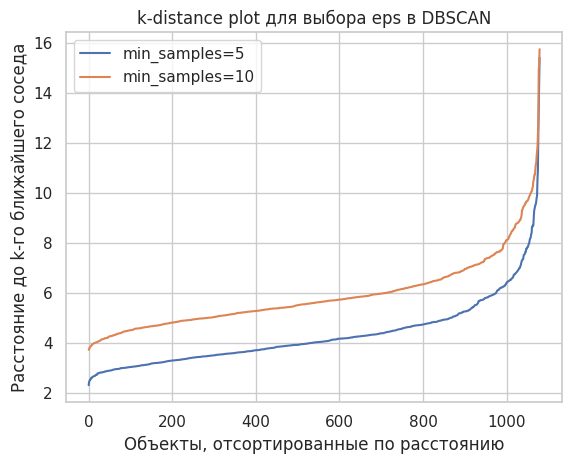

,5,10
0.10,3.068368,4.556236
0.25,3.466330,4.988402
0.50,4.030331,5.609544
0.75,4.784389,6.392935
0.90,5.974504,7.555427
0.95,6.859576,8.787909


In [16]:
neighbor_diagnostics = []

for min_samples in [5, 10]:
    distances, _ = NearestNeighbors(n_neighbors=min_samples).fit(X_scaled).kneighbors(X_scaled)
    kth_neighbor_distances = np.sort(distances[:, -1])

    neighbor_diagnostics.append(
        pd.Series(kth_neighbor_distances).quantile([0.1, 0.25, 0.5, 0.75, 0.9, 0.95]).rename(min_samples)
    )

    plt.plot(kth_neighbor_distances, label=f'min_samples={min_samples}')

plt.title('k-distance plot для выбора eps в DBSCAN')
plt.xlabel('Объекты, отсортированные по расстоянию')
plt.ylabel('Расстояние до k-го ближайшего соседа')
plt.legend()
plt.show()

pd.concat(neighbor_diagnostics, axis=1)

In [ ]:
results = []

# Собственная реализация K-Means++
model = CustomKMeansPlusPlus(n_clusters=N_CLUSTERS, n_init=20, random_state=RANDOM_STATE)
start = perf_counter()
labels = model.fit_predict(X_scaled)
fit_time = perf_counter() - start

results.append(
    evaluate_clustering(
        'CustomKMeansPlusPlus',
        {'n_clusters': N_CLUSTERS, 'n_init': 20},
        X_scaled,
        labels,
        fit_time,
        inertia=model.inertia_,
    )
)

# KMeans из sklearn
for n_init in [10, 20, 50]:
    model = KMeans(
        n_clusters=N_CLUSTERS,
        init='k-means++',
        n_init=n_init,
        random_state=RANDOM_STATE,
    )
    start = perf_counter()
    labels = model.fit_predict(X_scaled)
    fit_time = perf_counter() - start

    results.append(
        evaluate_clustering(
            'sklearn KMeans',
            {'n_clusters': N_CLUSTERS, 'n_init': n_init},
            X_scaled,
            labels,
            fit_time,
            inertia=model.inertia_,
        )
    )

# DBSCAN из sklearn
for eps in [6, 7, 8, 9, 10, 12]:
    for min_samples in [5, 10]:
        model = DBSCAN(eps=eps, min_samples=min_samples)
        start = perf_counter()
        labels = model.fit_predict(X_scaled)
        fit_time = perf_counter() - start

        results.append(
            evaluate_clustering(
                'sklearn DBSCAN',
                {'eps': eps, 'min_samples': min_samples},
                X_scaled,
                labels,
                fit_time,
            )
        )

results_df = pd.DataFrame(results)
results_df.head()

,model,params,fit_time_sec,n_clusters,noise_count,inertia,intra_cluster_distance,inter_cluster_distance,dunn_index,silhouette,adjusted_rand
0,CustomKMeansPlusPlus,"{'n_clusters': 2, 'n_init': 20}",0.126152,2,0,70064.595731,25.54736,1.455411,0.052626,0.143124,0.020695
1,sklearn KMeans,"{'n_clusters': 2, 'n_init': 10}",0.114329,2,0,70064.595731,25.54736,1.455411,0.052626,0.143124,0.020695
2,sklearn KMeans,"{'n_clusters': 2, 'n_init': 20}",0.129797,2,0,70064.595731,25.54736,1.455411,0.052626,0.143124,0.020695
3,sklearn KMeans,"{'n_clusters': 2, 'n_init': 50}",0.173328,2,0,70064.595731,25.54736,1.455411,0.052626,0.143124,0.020695
4,sklearn DBSCAN,"{'eps': 6, 'min_samples': 5}",0.051203,8,51,NaN,12.13579,11.601715,0.237712,-0.016115,0.008650


### Сравнение качества

Для `silhouette`, `inter_cluster_distance` и `dunn_index` больше — лучше. Для `intra_cluster_distance` меньше — лучше. `adjusted_rand` показывает, насколько найденные кластеры похожи на известные экспериментальные группы `class`.

In [18]:
comparison_columns = [
    'model',
    'params',
    'fit_time_sec',
    'n_clusters',
    'noise_count',
    'inertia',
    'intra_cluster_distance',
    'inter_cluster_distance',
    'dunn_index',
    'silhouette',
    'adjusted_rand',
]

results_df[comparison_columns].sort_values('silhouette', ascending=False).head(10)

,model,params,fit_time_sec,n_clusters,noise_count,inertia,intra_cluster_distance,inter_cluster_distance,dunn_index,silhouette,adjusted_rand
9,sklearn DBSCAN,"{'eps': 8, 'min_samples': 10}",0.052540,2,23,NaN,20.308267,9.367891,0.340773,0.369523,0.001713
11,sklearn DBSCAN,"{'eps': 9, 'min_samples': 10}",0.085502,2,12,NaN,21.538470,9.367891,0.312779,0.367192,0.001072
10,sklearn DBSCAN,"{'eps': 9, 'min_samples': 5}",0.082319,2,7,NaN,22.394424,9.367891,0.295868,0.365129,0.000629
8,sklearn DBSCAN,"{'eps': 8, 'min_samples': 5}",0.013125,3,10,NaN,17.860857,11.671911,0.279398,0.232227,0.001091
6,sklearn DBSCAN,"{'eps': 7, 'min_samples': 5}",0.085982,3,29,NaN,17.465698,11.939104,0.224546,0.212255,0.001409
0,CustomKMeansPlusPlus,"{'n_clusters': 2, 'n_init': 20}",0.126152,2,0,70064.595731,25.547360,1.455411,0.052626,0.143124,0.020695
1,sklearn KMeans,"{'n_clusters': 2, 'n_init': 10}",0.114329,2,0,70064.595731,25.547360,1.455411,0.052626,0.143124,0.020695
2,sklearn KMeans,"{'n_clusters': 2, 'n_init': 20}",0.129797,2,0,70064.595731,25.547360,1.455411,0.052626,0.143124,0.020695
3,sklearn KMeans,"{'n_clusters': 2, 'n_init': 50}",0.173328,2,0,70064.595731,25.547360,1.455411,0.052626,0.143124,0.020695
5,sklearn DBSCAN,"{'eps': 6, 'min_samples': 10}",0.045575,3,135,NaN,16.103990,6.760321,0.250876,0.085064,0.014560


In [19]:
best_by_model = (
    results_df.sort_values('silhouette', ascending=False)
    .groupby('model', as_index=False)
    .head(1)
    .sort_values('silhouette', ascending=False)
)

best_by_model[comparison_columns]

,model,params,fit_time_sec,n_clusters,noise_count,inertia,intra_cluster_distance,inter_cluster_distance,dunn_index,silhouette,adjusted_rand
9,sklearn DBSCAN,"{'eps': 8, 'min_samples': 10}",0.052540,2,23,NaN,20.308267,9.367891,0.340773,0.369523,0.001713
0,CustomKMeansPlusPlus,"{'n_clusters': 2, 'n_init': 20}",0.126152,2,0,70064.595731,25.547360,1.455411,0.052626,0.143124,0.020695
1,sklearn KMeans,"{'n_clusters': 2, 'n_init': 10}",0.114329,2,0,70064.595731,25.547360,1.455411,0.052626,0.143124,0.020695


### Визуальное сравнение моделей

Построим графики для лучших вариантов каждой модели: скорость обучения, качество кластеризации, внутрикластерные и межкластерные расстояния, количество кластеров и шумовых точек.

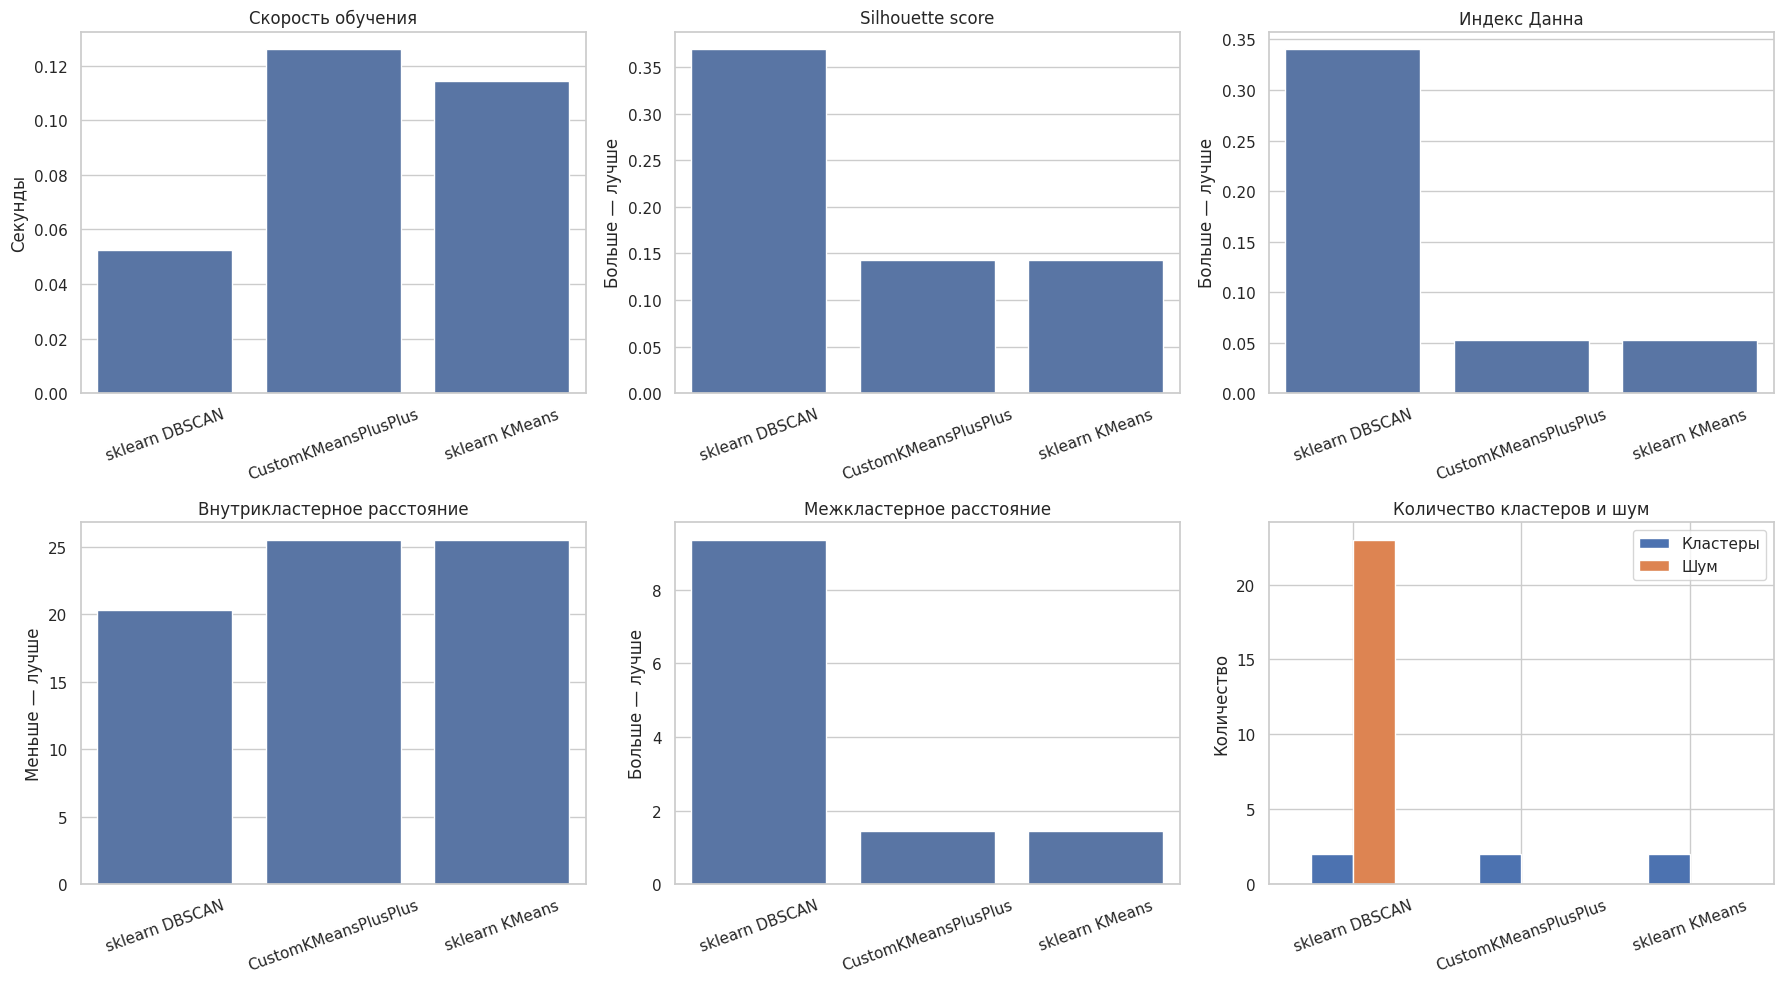

In [20]:
plot_df = best_by_model.copy()
plot_df['params_text'] = plot_df['params'].astype(str)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

sns.barplot(data=plot_df, x='model', y='fit_time_sec', ax=axes[0])
axes[0].set_title('Скорость обучения')
axes[0].set_xlabel('')
axes[0].set_ylabel('Секунды')

sns.barplot(data=plot_df, x='model', y='silhouette', ax=axes[1])
axes[1].set_title('Silhouette score')
axes[1].set_xlabel('')
axes[1].set_ylabel('Больше — лучше')

sns.barplot(data=plot_df, x='model', y='dunn_index', ax=axes[2])
axes[2].set_title('Индекс Данна')
axes[2].set_xlabel('')
axes[2].set_ylabel('Больше — лучше')

sns.barplot(data=plot_df, x='model', y='intra_cluster_distance', ax=axes[3])
axes[3].set_title('Внутрикластерное расстояние')
axes[3].set_xlabel('')
axes[3].set_ylabel('Меньше — лучше')

sns.barplot(data=plot_df, x='model', y='inter_cluster_distance', ax=axes[4])
axes[4].set_title('Межкластерное расстояние')
axes[4].set_xlabel('')
axes[4].set_ylabel('Больше — лучше')

plot_df[['model', 'n_clusters', 'noise_count']].set_index('model').plot(
    kind='bar', ax=axes[5]
)
axes[5].set_title('Количество кластеров и шум')
axes[5].set_xlabel('')
axes[5].set_ylabel('Количество')
axes[5].legend(['Кластеры', 'Шум'])

for ax in axes:
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()

### Влияние параметров DBSCAN

Для DBSCAN отдельно посмотрим, как `eps` и `min_samples` влияют на число кластеров, количество шума и `silhouette`.

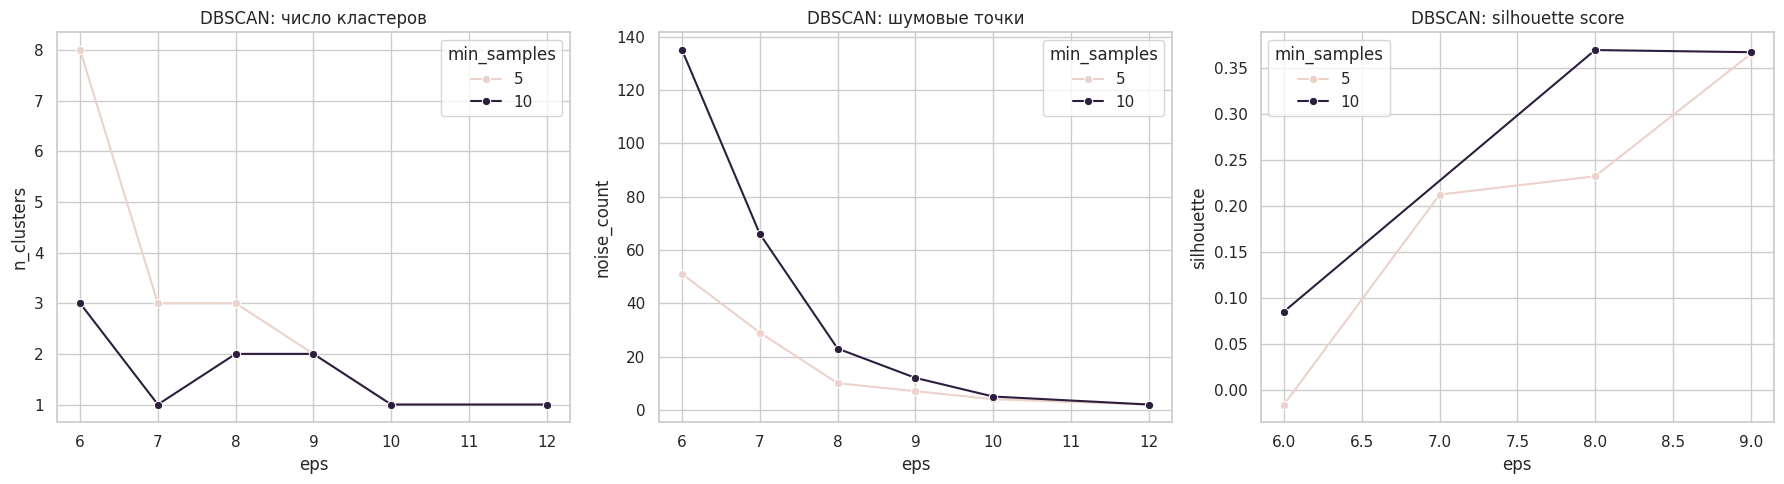

In [21]:
dbscan_results = results_df[results_df['model'] == 'sklearn DBSCAN'].copy()
dbscan_results['eps'] = dbscan_results['params'].apply(lambda params: params['eps'])
dbscan_results['min_samples'] = dbscan_results['params'].apply(lambda params: params['min_samples'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.lineplot(
    data=dbscan_results,
    x='eps',
    y='n_clusters',
    hue='min_samples',
    marker='o',
    ax=axes[0],
)
axes[0].set_title('DBSCAN: число кластеров')

sns.lineplot(
    data=dbscan_results,
    x='eps',
    y='noise_count',
    hue='min_samples',
    marker='o',
    ax=axes[1],
)
axes[1].set_title('DBSCAN: шумовые точки')

sns.lineplot(
    data=dbscan_results,
    x='eps',
    y='silhouette',
    hue='min_samples',
    marker='o',
    ax=axes[2],
)
axes[2].set_title('DBSCAN: silhouette score')

plt.tight_layout()

### Интерпретация результатов

Для `CustomKMeansPlusPlus` и `sklearn KMeans` количество кластеров выбирается по исследованию `inertia` и `silhouette_score`. В текущих данных лучший `silhouette_score` для K-Means-подходов обычно выбирает небольшое число крупных кластеров, а не обязательно 8 экспериментальных групп.

Для `DBSCAN` число кластеров не задаётся напрямую. Разные значения `eps` и `min_samples` могут давать разное количество плотностных областей: маленький `eps` дробит данные на много кластеров, большой `eps` объединяет почти всё в один кластер. Поэтому DBSCAN оцениваем отдельно по числу найденных кластеров, количеству шума, `silhouette`, расстояниям и индексу Данна.

Если DBSCAN находит больше кластеров, чем K-Means, это не противоречие: алгоритмы используют разные представления о кластерах. K-Means ищет компактные группы вокруг центров, а DBSCAN ищет плотные области произвольной формы.

### Сравнение кластеров с факторами эксперимента

Теперь проверим, совпадают ли найденные кластеры с отдельными биологическими факторами: `Genotype` (контрольные мыши и trisomy-мыши), `Treatment` (saline и memantine), `Behavior` (стимулировались к обучению или нет), а также с полной группой `class`.

In [22]:
best_labels = {}

custom_model = CustomKMeansPlusPlus(n_clusters=N_CLUSTERS, n_init=20, random_state=RANDOM_STATE)
best_labels['CustomKMeansPlusPlus'] = custom_model.fit_predict(X_scaled)

best_kmeans_params = best_by_model.loc[
    best_by_model['model'] == 'sklearn KMeans', 'params'
].iloc[0]
kmeans_model = KMeans(
    n_clusters=best_kmeans_params['n_clusters'],
    init='k-means++',
    n_init=best_kmeans_params['n_init'],
    random_state=RANDOM_STATE,
)
best_labels['sklearn KMeans'] = kmeans_model.fit_predict(X_scaled)

best_dbscan_params = best_by_model.loc[
    best_by_model['model'] == 'sklearn DBSCAN', 'params'
].iloc[0]
dbscan_model = DBSCAN(
    eps=best_dbscan_params['eps'],
    min_samples=best_dbscan_params['min_samples'],
)
best_labels['sklearn DBSCAN'] = dbscan_model.fit_predict(X_scaled)

cluster_labels_df = pd.DataFrame(best_labels)
cluster_labels_df.head()

,CustomKMeansPlusPlus,sklearn KMeans,sklearn DBSCAN
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,0,1,0


In [23]:
factor_columns = ['Genotype', 'Treatment', 'Behavior', 'class']
factor_scores = []

for model_name, labels in best_labels.items():
    for factor in factor_columns:
        factor_codes, _ = pd.factorize(df[factor])
        factor_scores.append(
            {
                'model': model_name,
                'factor': factor,
                'adjusted_rand': adjusted_rand_score(factor_codes, labels),
            }
        )

factor_scores_df = pd.DataFrame(factor_scores)
factor_scores_df.pivot(index='model', columns='factor', values='adjusted_rand')

factor,Behavior,Genotype,Treatment,class
model,,,,
CustomKMeansPlusPlus,0.030055,0.004520,0.000689,0.020695
sklearn DBSCAN,0.004412,-0.003548,0.006708,0.001713
sklearn KMeans,0.030055,0.004520,0.000689,0.020695


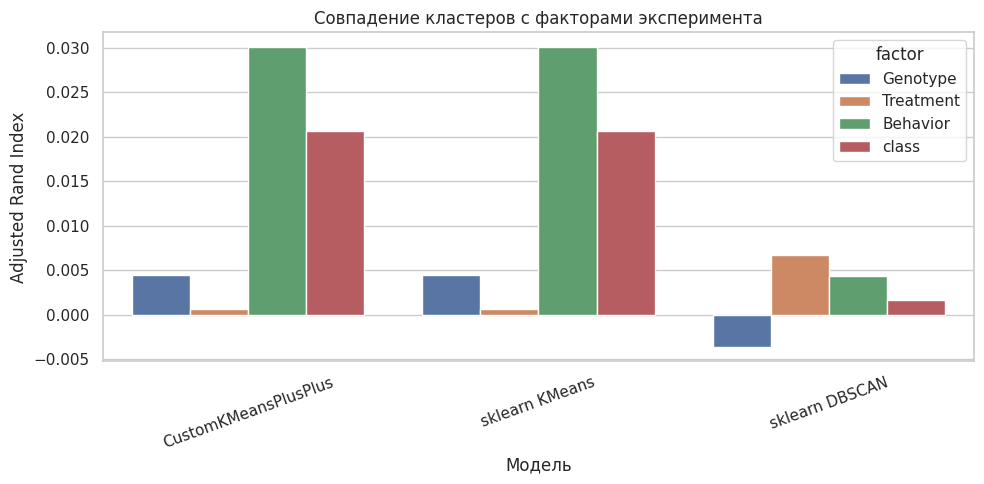

In [24]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=factor_scores_df,
    x='model',
    y='adjusted_rand',
    hue='factor',
)
plt.title('Совпадение кластеров с факторами эксперимента')
plt.xlabel('Модель')
plt.ylabel('Adjusted Rand Index')
plt.xticks(rotation=20)
plt.tight_layout()

In [25]:
for model_name, labels in best_labels.items():
    print(f'\n{model_name}: Genotype')
    display(pd.crosstab(labels, df['Genotype'], normalize='index').round(3))

    print(f'{model_name}: Treatment')
    display(pd.crosstab(labels, df['Treatment'], normalize='index').round(3))


CustomKMeansPlusPlus: Genotype


Genotype,Control,Ts65Dn
row_0,,
0,0.489,0.511
1,0.556,0.444


CustomKMeansPlusPlus: Treatment


Treatment,Memantine,Saline
row_0,,
0,0.509,0.491
1,0.542,0.458



sklearn KMeans: Genotype


...

Treatment,Memantine,Saline
row_0,,
0,0.542,0.458
1,0.509,0.491



sklearn DBSCAN: Genotype


Genotype,Control,Ts65Dn
row_0,,
-1,0.913,0.087
0,0.514,0.486
1,1.000,0.000


sklearn DBSCAN: Treatment


Treatment,Memantine,Saline
row_0,,
-1,0.217,0.783
0,0.540,0.460
1,0.000,1.000


В этих таблицах строки — найденные кластеры, а столбцы — реальные факторы эксперимента. Если в строке почти вся доля находится в одном столбце, значит кластер хорошо соответствует этому фактору. Если доли смешаны, значит кластер не совпадает напрямую с этим признаком.

In [26]:
best_factor_match = factor_scores_df.sort_values('adjusted_rand', ascending=False).iloc[0]

print('Лучшее совпадение кластеров с фактором эксперимента:')
print(f"Модель: {best_factor_match['model']}")
print(f"Фактор: {best_factor_match['factor']}")
print(f"Adjusted Rand Index: {best_factor_match['adjusted_rand']:.3f}")

if best_factor_match['adjusted_rand'] < 0.1:
    print('Вывод: прямого совпадения кластеров с экспериментальными факторами почти нет.')
elif best_factor_match['adjusted_rand'] < 0.3:
    print('Вывод: есть слабое совпадение, но кластеры сильно смешаны.')
else:
    print('Вывод: кластеры заметно согласуются с одним из факторов эксперимента.')

Лучшее совпадение кластеров с фактором эксперимента:
Модель: CustomKMeansPlusPlus
Фактор: Behavior
Adjusted Rand Index: 0.030
Вывод: прямого совпадения кластеров с экспериментальными факторами почти нет.


## Дополнительное задание

Снизим размерность данных с помощью PCA и проверим, как меняется качество кластеризации для всех трёх моделей при разном количестве главных компонент. Также визуализируем данные в 2D через PCA и t-SNE.

### PCA: качество кластеризации при разном числе компонент

PCA строит новые признаки — главные компоненты, которые сохраняют как можно больше разброса исходных данных. Проверим несколько вариантов размерности и заново обучим `CustomKMeansPlusPlus`, `sklearn KMeans` и `DBSCAN`.

In [27]:
pca_components_list = [2, 3, 5, 10, 20, 30, 50]
pca_results = []
pca_dbscan_search_results = []


def dbscan_eps_candidates(X_eval, min_samples):
    distances, _ = NearestNeighbors(n_neighbors=min_samples).fit(X_eval).kneighbors(X_eval)
    kth_neighbor_distances = np.sort(distances[:, -1])
    quantile_candidates = np.quantile(kth_neighbor_distances, [0.5, 0.65, 0.75, 0.85, 0.9, 0.95])
    return sorted(set(np.round(quantile_candidates, 3)))


for n_components in pca_components_list:
    pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
    X_pca = pca.fit_transform(X_scaled)
    explained_variance = pca.explained_variance_ratio_.sum()

    model = CustomKMeansPlusPlus(n_clusters=N_CLUSTERS, n_init=20, random_state=RANDOM_STATE)
    start = perf_counter()
    labels = model.fit_predict(X_pca)
    fit_time = perf_counter() - start
    metrics = evaluate_clustering(
        'CustomKMeansPlusPlus',
        {'n_clusters': N_CLUSTERS, 'n_init': 20, 'pca_components': n_components},
        X_pca,
        labels,
        fit_time,
        inertia=model.inertia_,
    )
    metrics['pca_components'] = n_components
    metrics['explained_variance'] = explained_variance
    pca_results.append(metrics)

    model = KMeans(
        n_clusters=N_CLUSTERS,
        init='k-means++',
        n_init=20,
        random_state=RANDOM_STATE,
    )
    start = perf_counter()
    labels = model.fit_predict(X_pca)
    fit_time = perf_counter() - start
    metrics = evaluate_clustering(
        'sklearn KMeans',
        {'n_clusters': N_CLUSTERS, 'n_init': 20, 'pca_components': n_components},
        X_pca,
        labels,
        fit_time,
        inertia=model.inertia_,
    )
    metrics['pca_components'] = n_components
    metrics['explained_variance'] = explained_variance
    pca_results.append(metrics)

    dbscan_candidates = []
    for min_samples in [5, 10]:
        for eps in dbscan_eps_candidates(X_pca, min_samples):
            model = DBSCAN(eps=eps, min_samples=min_samples)
            start = perf_counter()
            labels = model.fit_predict(X_pca)
            fit_time = perf_counter() - start
            metrics = evaluate_clustering(
                'sklearn DBSCAN',
                {
                    'eps': float(eps),
                    'min_samples': min_samples,
                    'pca_components': n_components,
                },
                X_pca,
                labels,
                fit_time,
            )
            metrics['pca_components'] = n_components
            metrics['explained_variance'] = explained_variance
            dbscan_candidates.append(metrics)
            pca_dbscan_search_results.append(metrics.copy())

    valid_dbscan_candidates = [
        metrics for metrics in dbscan_candidates
        if not np.isnan(metrics['silhouette'])
    ]
    if valid_dbscan_candidates:
        best_dbscan_metrics = max(valid_dbscan_candidates, key=lambda metrics: metrics['silhouette'])
    else:
        best_dbscan_metrics = max(dbscan_candidates, key=lambda metrics: metrics['n_clusters'])

    pca_results.append(best_dbscan_metrics)

pca_results_df = pd.DataFrame(pca_results)
pca_dbscan_search_df = pd.DataFrame(pca_dbscan_search_results)
pca_results_df[comparison_columns + ['pca_components', 'explained_variance']].sort_values(
    'silhouette', ascending=False
).head(10)

,model,params,fit_time_sec,n_clusters,noise_count,inertia,intra_cluster_distance,inter_cluster_distance,dunn_index,silhouette,adjusted_rand,pca_components,explained_variance
11,sklearn DBSCAN,"{'eps': 6.097, 'min_samples': 10, 'pca_compone...",0.037473,2,9,NaN,18.640629,8.394553,0.315690,0.438850,0.000672,10,0.805695
14,sklearn DBSCAN,"{'eps': 7.452, 'min_samples': 10, 'pca_compone...",0.005075,2,11,NaN,20.409013,8.779571,0.312867,0.390595,0.001135,20,0.902016
17,sklearn DBSCAN,"{'eps': 8.056, 'min_samples': 10, 'pca_compone...",0.004480,2,13,NaN,20.559012,8.975351,0.316964,0.378901,0.000999,30,0.947859
20,sklearn DBSCAN,"{'eps': 7.389, 'min_samples': 10, 'pca_compone...",0.035256,2,31,NaN,20.220579,9.260449,0.337272,0.374207,0.002276,50,0.985579
0,CustomKMeansPlusPlus,"{'n_clusters': 2, 'n_init': 20, 'pca_component...",0.058075,2,0,22106.120426,21.076859,0.205587,0.008518,0.330609,0.020872,2,0.422611
1,sklearn KMeans,"{'n_clusters': 2, 'n_init': 20, 'pca_component...",0.122038,2,0,22106.148350,21.076859,0.168481,0.006980,0.330349,0.020973,2,0.422611
8,sklearn DBSCAN,"{'eps': 3.89, 'min_samples': 5, 'pca_component...",0.014792,2,23,NaN,16.851187,5.227177,0.206226,0.313126,0.001869,5,0.653283
3,CustomKMeansPlusPlus,"{'n_clusters': 2, 'n_init': 20, 'pca_component...",0.061361,2,0,30693.923145,21.571801,0.345556,0.014187,0.264655,0.021172,3,0.526046
4,sklearn KMeans,"{'n_clusters': 2, 'n_init': 20, 'pca_component...",0.133762,2,0,30693.923145,21.571801,0.345556,0.014187,0.264655,0.021172,3,0.526046
2,sklearn DBSCAN,"{'eps': 1.244, 'min_samples': 5, 'pca_componen...",0.006197,3,32,NaN,9.279204,1.118615,0.039727,0.257497,0.000438,2,0.422611


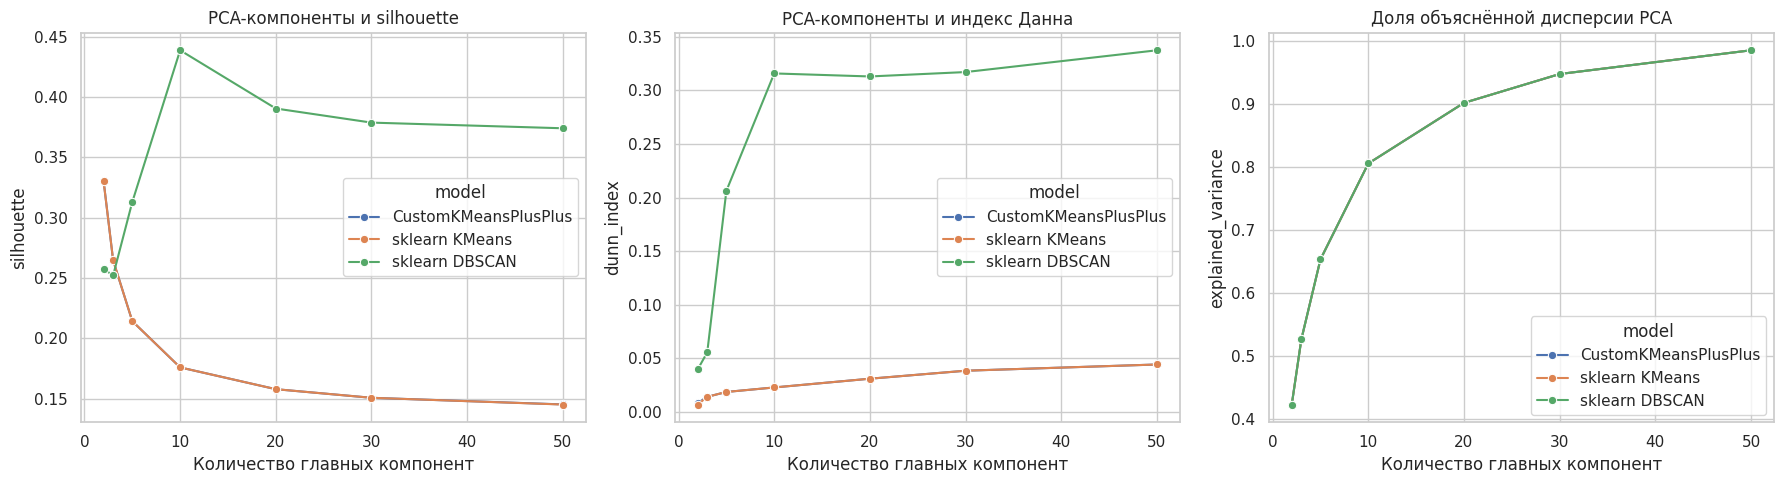

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.lineplot(
    data=pca_results_df,
    x='pca_components',
    y='silhouette',
    hue='model',
    marker='o',
    ax=axes[0],
)
axes[0].set_title('PCA-компоненты и silhouette')
axes[0].set_xlabel('Количество главных компонент')

sns.lineplot(
    data=pca_results_df,
    x='pca_components',
    y='dunn_index',
    hue='model',
    marker='o',
    ax=axes[1],
)
axes[1].set_title('PCA-компоненты и индекс Данна')
axes[1].set_xlabel('Количество главных компонент')

sns.lineplot(
    data=pca_results_df,
    x='pca_components',
    y='explained_variance',
    hue='model',
    marker='o',
    ax=axes[2],
)
axes[2].set_title('Доля объяснённой дисперсии PCA')
axes[2].set_xlabel('Количество главных компонент')

plt.tight_layout()

In [29]:
best_pca_result = pca_results_df.sort_values('silhouette', ascending=False).iloc[0]

print('Лучший результат после PCA по silhouette_score:')
print(f"Модель: {best_pca_result['model']}")
print(f"Количество PCA-компонент: {int(best_pca_result['pca_components'])}")
print(f"Доля объяснённой дисперсии: {best_pca_result['explained_variance']:.3f}")
print(f"Silhouette: {best_pca_result['silhouette']:.3f}")
print(f"Dunn index: {best_pca_result['dunn_index']:.3f}")
print(f"Число кластеров: {int(best_pca_result['n_clusters'])}")
print(f"Шумовых точек: {int(best_pca_result['noise_count'])}")

if best_pca_result['pca_components'] <= 3:
    print('Вывод: существенная кластерная структура видна уже в малом числе главных компонент.')
else:
    print('Вывод: для лучшего качества требуется больше компонент, 2D-проекция может терять важную часть структуры.')

Лучший результат после PCA по silhouette_score:
Модель: sklearn DBSCAN
Количество PCA-компонент: 10
Доля объяснённой дисперсии: 0.806
Silhouette: 0.439
Dunn index: 0.316
Число кластеров: 2
Шумовых точек: 9
Вывод: для лучшего качества требуется больше компонент, 2D-проекция может терять важную часть структуры.


### Визуализация кластеров через PCA и t-SNE

Сначала построим 2D-проекцию через PCA. Затем построим t-SNE: перед ним дополнительно снизим размерность через PCA до 30 компонент, чтобы t-SNE работал быстрее и стабильнее.

In [30]:
X_pca_2d = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_scaled)

X_pca_for_tsne = PCA(n_components=30, random_state=RANDOM_STATE).fit_transform(X_scaled)
X_tsne_2d = TSNE(
    n_components=2,
    perplexity=30,
    init='pca',
    learning_rate='auto',
    random_state=RANDOM_STATE,
).fit_transform(X_pca_for_tsne)

projection_df = pd.DataFrame(
    {
        'pca_1': X_pca_2d[:, 0],
        'pca_2': X_pca_2d[:, 1],
        'tsne_1': X_tsne_2d[:, 0],
        'tsne_2': X_tsne_2d[:, 1],
        'Genotype': df['Genotype'],
        'Treatment': df['Treatment'],
        'Behavior': df['Behavior'],
        'class': df['class'],
    }
)

for model_name, labels in best_labels.items():
    projection_df[model_name] = labels.astype(str)

projection_df.head()

,pca_1,pca_2,tsne_1,tsne_2,Genotype,Treatment,Behavior,class,CustomKMeansPlusPlus,sklearn KMeans,sklearn DBSCAN
0,4.716300,-5.313455,-3.381887,-34.817780,Control,Memantine,C/S,c-CS-m,1,0,0
1,3.101371,-5.414466,-3.647063,-34.630264,Control,Memantine,C/S,c-CS-m,1,0,0
2,3.219638,-5.622423,-3.685562,-34.642460,Control,Memantine,C/S,c-CS-m,1,0,0
3,0.702445,-3.932709,-6.022110,-31.094351,Control,Memantine,C/S,c-CS-m,1,0,0
4,-0.345755,-4.272749,-6.521119,-30.963913,Control,Memantine,C/S,c-CS-m,0,1,0


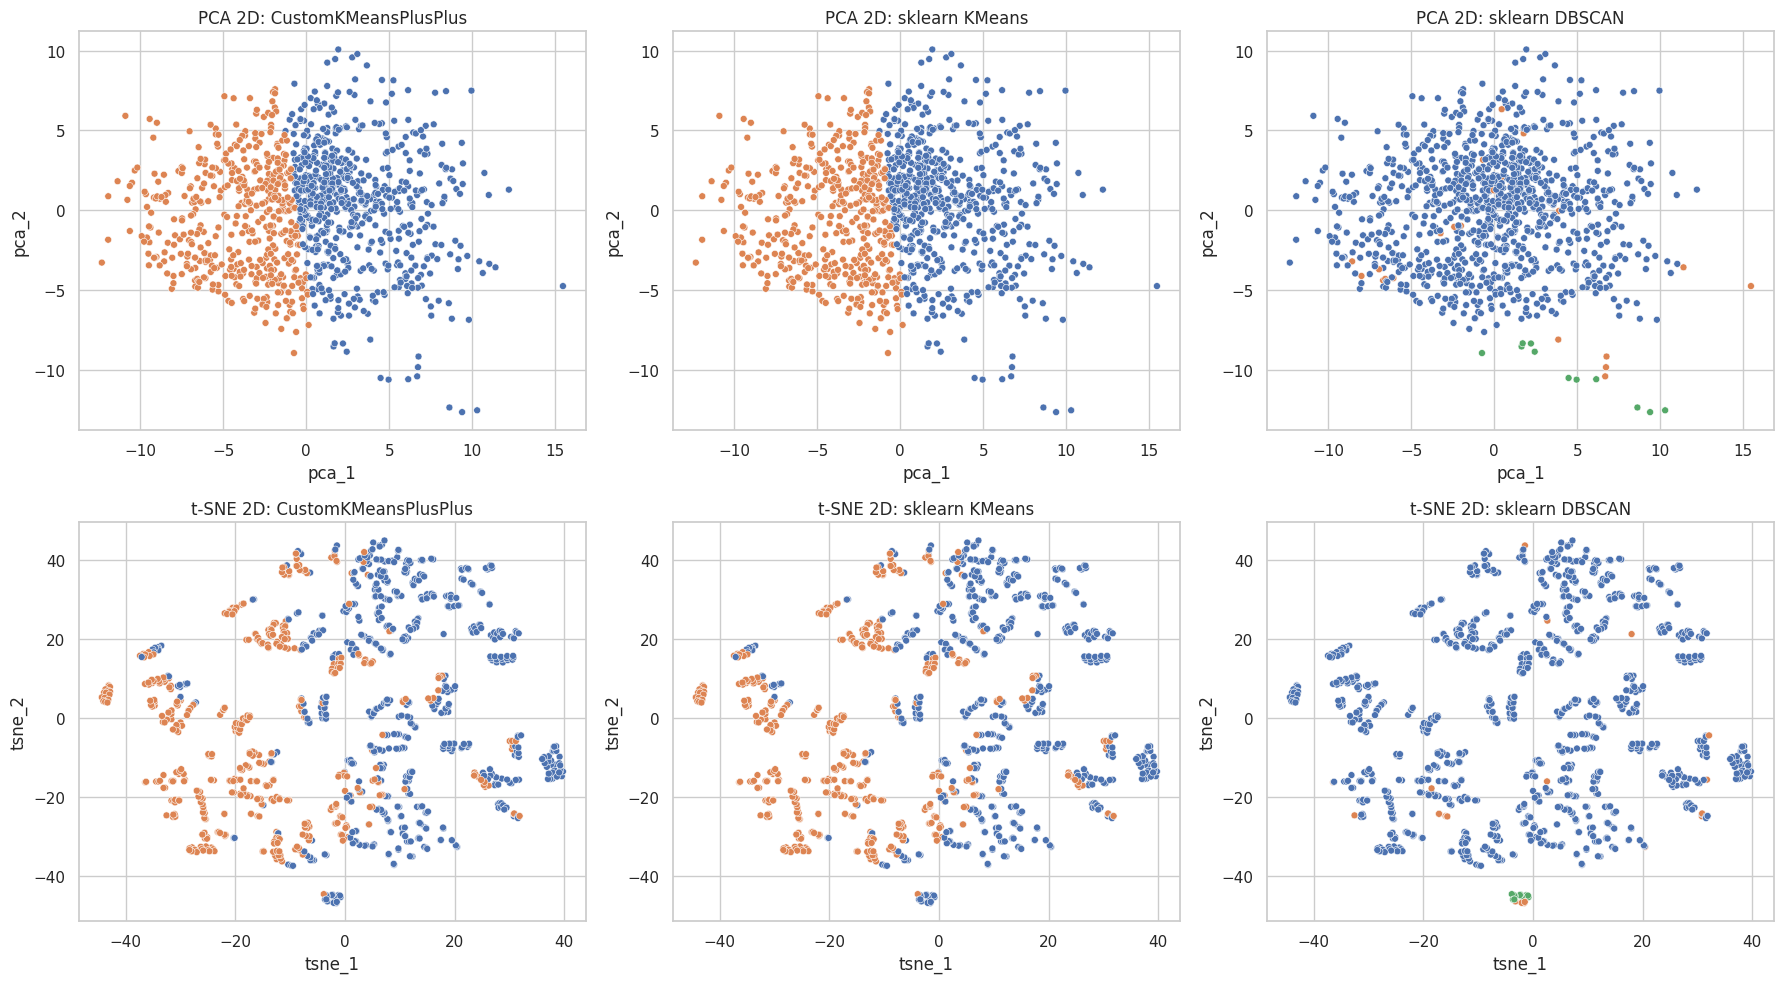

In [31]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, model_name in zip(axes[0], best_labels.keys()):
    sns.scatterplot(
        data=projection_df,
        x='pca_1',
        y='pca_2',
        hue=model_name,
        s=25,
        ax=ax,
        legend=False,
    )
    ax.set_title(f'PCA 2D: {model_name}')

for ax, model_name in zip(axes[1], best_labels.keys()):
    sns.scatterplot(
        data=projection_df,
        x='tsne_1',
        y='tsne_2',
        hue=model_name,
        s=25,
        ax=ax,
        legend=False,
    )
    ax.set_title(f't-SNE 2D: {model_name}')

plt.tight_layout()

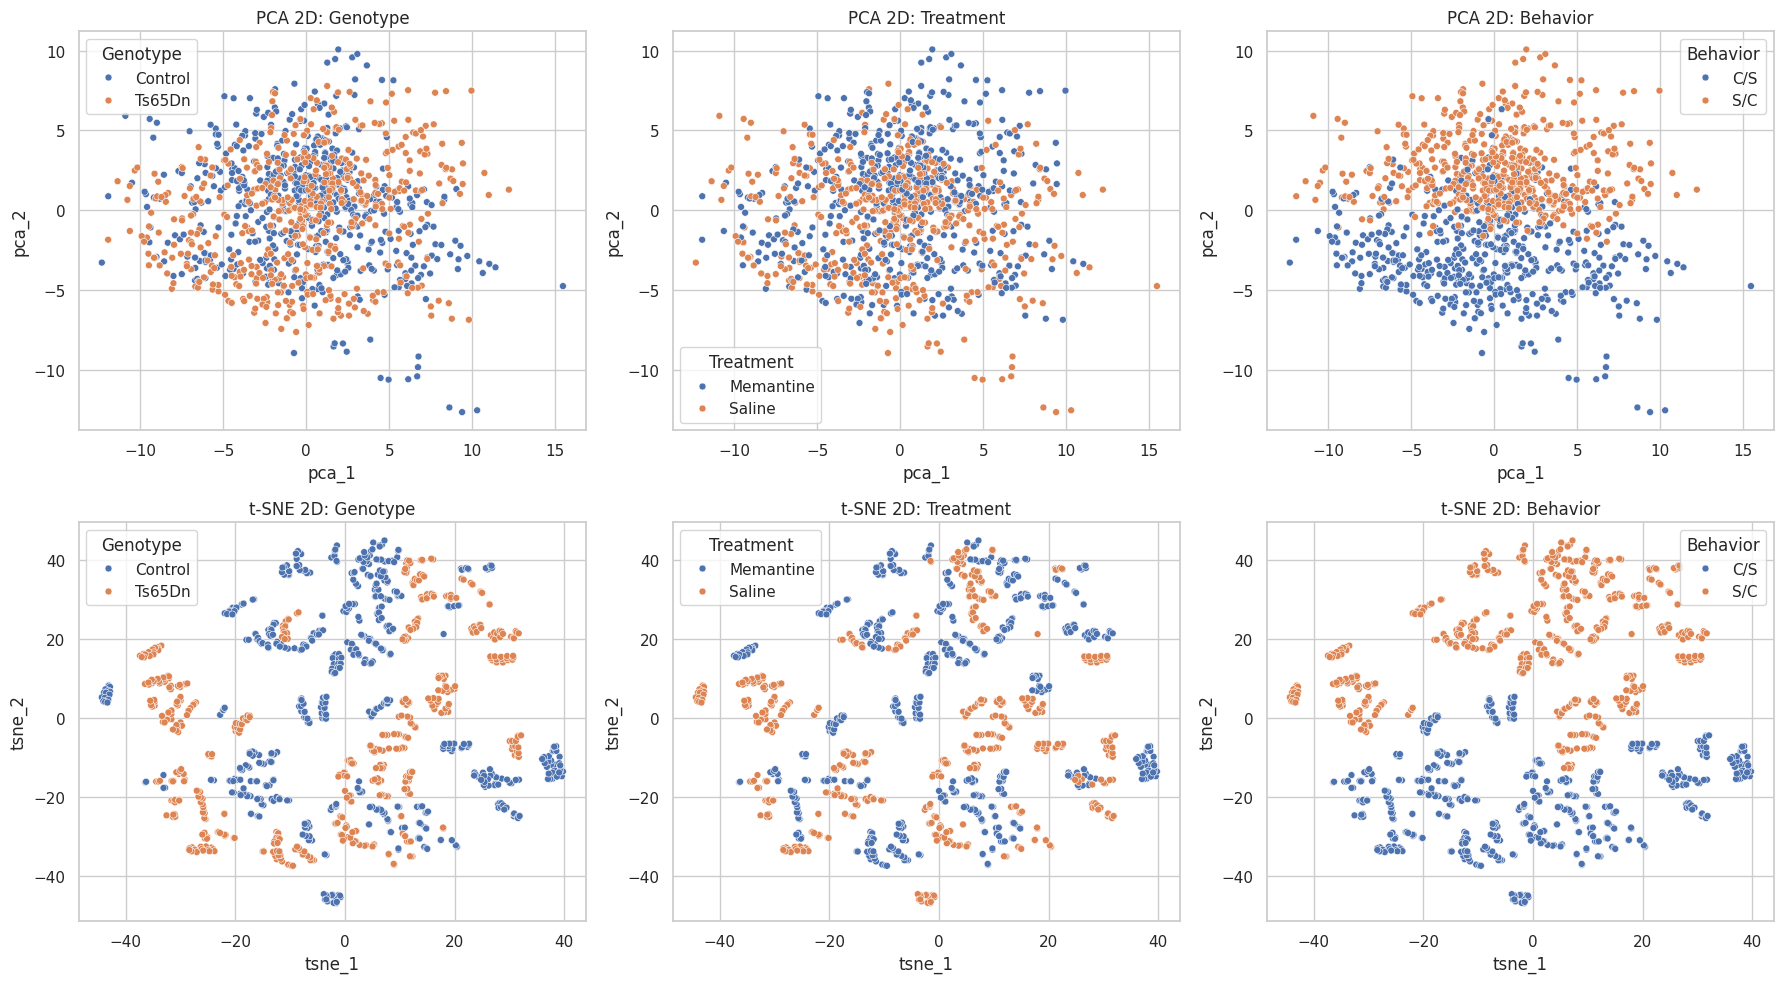

In [32]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
factors_to_plot = ['Genotype', 'Treatment', 'Behavior']

for ax, factor in zip(axes[0], factors_to_plot):
    sns.scatterplot(
        data=projection_df,
        x='pca_1',
        y='pca_2',
        hue=factor,
        s=25,
        ax=ax,
    )
    ax.set_title(f'PCA 2D: {factor}')

for ax, factor in zip(axes[1], factors_to_plot):
    sns.scatterplot(
        data=projection_df,
        x='tsne_1',
        y='tsne_2',
        hue=factor,
        s=25,
        ax=ax,
    )
    ax.set_title(f't-SNE 2D: {factor}')

plt.tight_layout()

По этим графикам можно визуально оценить, есть ли явное разделение данных. Ниже дополнительно посчитаем `silhouette_score` прямо в 2D-проекциях PCA и t-SNE, чтобы сделать вывод не только визуально, но и численно.

In [33]:
projection_scores = []
projection_spaces = {
    'PCA 2D': projection_df[['pca_1', 'pca_2']].to_numpy(),
    't-SNE 2D': projection_df[['tsne_1', 'tsne_2']].to_numpy(),
}

for projection_name, projection_values in projection_spaces.items():
    for model_name, labels in best_labels.items():
        score = safe_silhouette_score(projection_values, labels)
        if not np.isnan(score):
            projection_scores.append(
                {
                    'projection': projection_name,
                    'label_type': 'cluster',
                    'name': model_name,
                    'silhouette': score,
                }
            )

    for factor in factors_to_plot:
        factor_codes, _ = pd.factorize(projection_df[factor])
        projection_scores.append(
            {
                'projection': projection_name,
                'label_type': 'factor',
                'name': factor,
                'silhouette': silhouette_score(projection_values, factor_codes),
            }
        )

projection_scores_df = pd.DataFrame(projection_scores)
display(projection_scores_df.sort_values('silhouette', ascending=False))

best_projection = projection_scores_df.sort_values('silhouette', ascending=False).iloc[0]
print('Лучшее визуальное разделение в 2D-проекциях:')
print(f"Проекция: {best_projection['projection']}")
print(f"Тип меток: {best_projection['label_type']}")
print(f"Метки: {best_projection['name']}")
print(f"Silhouette в 2D: {best_projection['silhouette']:.3f}")

if best_projection['silhouette'] < 0.1:
    print('Вывод: в 2D-проекциях явного разделения почти не видно.')
elif best_projection['silhouette'] < 0.3:
    print('Вывод: разделение слабое или умеренное, группы частично смешиваются.')
else:
    print('Вывод: в выбранной 2D-проекции есть заметное разделение.')

,projection,label_type,name,silhouette
2,PCA 2D,cluster,sklearn DBSCAN,0.406493
11,t-SNE 2D,factor,Behavior,0.379584
1,PCA 2D,cluster,sklearn KMeans,0.330937
0,PCA 2D,cluster,CustomKMeansPlusPlus,0.330937
5,PCA 2D,factor,Behavior,0.214327
7,t-SNE 2D,cluster,sklearn KMeans,0.189994
6,t-SNE 2D,cluster,CustomKMeansPlusPlus,0.189994
8,t-SNE 2D,cluster,sklearn DBSCAN,0.148981
9,t-SNE 2D,factor,Genotype,0.036169
10,t-SNE 2D,factor,Treatment,0.025262


Лучшее визуальное разделение в 2D-проекциях:
Проекция: PCA 2D
Тип меток: cluster
Метки: sklearn DBSCAN
Silhouette в 2D: 0.406
Вывод: в выбранной 2D-проекции есть заметное разделение.
